<span style="font-weight:bold; font-size: 3rem; color:#333;">- Part 03: Training pipeline for Train Delay Data (Two-Stage Model)</span>

## 🗒️ Overview

This notebook downloads stored data from feature groups and uses it to train a model

It performs the following steps:

1. 


### 📝 Imports

In [40]:
import os
import datetime
import pandas as pd
import requests
import hopsworks_utils
import datetime as dt
from dotenv import load_dotenv
#import hopsworks
from typing import Any, Dict, List, Optional, Tuple


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

True

## 📡 Connect to Hopsworks Feature Store

In [41]:
# Optional: Hopsworks storage (not required)
try:
    project = hopsworks_utils.HopsworksInterface()
    print("Hopsworks login OK")
except Exception as e:
    project = None
    print("Hopsworks not configured / login failed (OK). Proceeding without it.")
    print("Reason:", repr(e))

#train_feature_df = project.get("train_stop_events_labeled")

#uncoment the below line when weather features are stored
#weather_df = project.get("weather_features") 


HOPSWORKS_API_KEY exists: True
HOPSWORKS_API_KEY length: 81
2026-01-06 16:42:35,517 INFO: Closing external client and cleaning up certificates.
2026-01-06 16:42:35,522 INFO: Connection closed.
2026-01-06 16:42:35,525 INFO: Initializing external client
2026-01-06 16:42:35,527 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-01-06 16:42:36,447 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/2182
Hopsworks login OK


In [42]:
import os, json, glob
import numpy as np
import pandas as pd

from sklearn.model_selection import ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb  # <--- NEW

from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    brier_score_loss,
    mean_absolute_error, mean_squared_error
)

import joblib
import matplotlib.pyplot as plt


## 📥 Load model-ready datasets (from Part 02)

Expected files (Parquet) in the working directory (or `/mnt/data`):
- `pred_train.parquet`, `pred_val.parquet`, `pred_test.parquet`
- `react_train.parquet`, `react_val.parquet`, `react_test.parquet`

If your filenames differ, update the `PATHS` dict below.

In [43]:
import os
import pandas as pd
import json

# ---- Locate files (adjust if needed) ----
# Add "data/feature_pipeline_outputs" to this list
CAND_DIRS = [
    "data/feature_pipeline_outputs", 
    "data", 
    "."
]

def _find_file(name: str):
    for d in CAND_DIRS:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    return None

PATHS = {
    "pred_train": _find_file("pred_train.parquet"),
    "pred_val": _find_file("pred_val.parquet"),
    "pred_test": _find_file("pred_test.parquet"),
    "react_train": _find_file("react_train.parquet"),
    "react_val": _find_file("react_val.parquet"),
    "react_test": _find_file("react_test.parquet"),
    "feature_meta": _find_file("feature_metadata.json"),
}

missing = [k for k,v in PATHS.items() if v is None and k != "feature_meta"]
if missing:
    raise FileNotFoundError(
        "Missing required Part-02 outputs: " + ", ".join(missing) +" Make sure you ran 2_train_feature_pipeline and saved the parquet splits into /mnt/data."
    )

pred_train = pd.read_parquet(PATHS["pred_train"])
pred_val   = pd.read_parquet(PATHS["pred_val"])
pred_test  = pd.read_parquet(PATHS["pred_test"])

react_train = pd.read_parquet(PATHS["react_train"])
react_val   = pd.read_parquet(PATHS["react_val"])
react_test  = pd.read_parquet(PATHS["react_test"])

print("Predictive splits:", len(pred_train), len(pred_val), len(pred_test))
print("Reactive splits:", len(react_train), len(react_val), len(react_test))

feature_meta = None
if PATHS["feature_meta"]:
    with open(PATHS["feature_meta"], "r") as f:
        feature_meta = json.load(f)
    print("Loaded feature metadata")


Predictive splits: 41698 17917 16461
Reactive splits: 2113 2316 4665
Loaded feature metadata


## 🧼 Prepare features / labels

We train:
- **Predictive (classification):** label `y_delay_within_horizon`
- **Reactive (regression):** target `additional_delay_min` (how much worse it gets from this event)

If you prefer `final_delay_min` as the reactive target, change `REACTIVE_TARGET` below.

In [44]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV


PRED_LABEL = "y_delay_within_horizon"
REACTIVE_TARGET = "additional_delay_min"  # or "final_delay_min"

# Drop non-feature columns if present
NON_FEATURES_COMMON = {
    PRED_LABEL,
    "final_delay_min", "additional_delay_min", "delay_min","reason_code", "reason_text", "reason_desc", 
    "train_id", "train_run_id", "InformationOwner",
    "scheduled_time", "estimated_time", "actual_time", "observed_time",
    "event_time", "date",
}



def split_Xy(df: pd.DataFrame, y_col: str):
    y = df[y_col].copy()
    X = df.drop(columns=[c for c in df.columns if c in NON_FEATURES_COMMON and c != y_col], errors="ignore")
    # also ensure y removed
    X = X.drop(columns=[y_col], errors="ignore")
    return X, y

X_pred_train, y_pred_train = split_Xy(pred_train, PRED_LABEL)
X_pred_val,   y_pred_val   = split_Xy(pred_val, PRED_LABEL)
X_pred_test,  y_pred_test  = split_Xy(pred_test, PRED_LABEL)

X_re_train, y_re_train = split_Xy(react_train, REACTIVE_TARGET)
X_re_val,   y_re_val   = split_Xy(react_val, REACTIVE_TARGET)
X_re_test,  y_re_test  = split_Xy(react_test, REACTIVE_TARGET)



# --- 1. Robust Feature Type Inference ---
def infer_feature_types(X: pd.DataFrame):
    # Explicitly select all text/categorical types
    cat = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    # All remaining columns are numeric
    num = [c for c in X.columns if c not in cat]
    return cat, num

# --- 2. Clean Data (Drop problematic columns) ---
# reason_text: Free text (high cardinality) -> causes memory issues or noise
# trigger_time: Datetime objects -> crash numeric imputers
cols_to_drop = ["reason_text", "trigger_time"]

for df in [X_pred_train, X_pred_val, X_pred_test, X_re_train, X_re_val, X_re_test]:
    existing_drop = [c for c in cols_to_drop if c in df.columns]
    if existing_drop:
        df.drop(columns=existing_drop, inplace=True)

# Re-infer types with the fixed function
cat_pred, num_pred = infer_feature_types(X_pred_train)
cat_re,   num_re   = infer_feature_types(X_re_train)

print(f"Predictive: {len(cat_pred)} cat, {len(num_pred)} num")
print(f"Reactive:   {len(cat_re)} cat, {len(num_re)} num")



Predictive: 6 cat, 29 num
Reactive:   6 cat, 30 num


In [45]:
display(X_pred_train)
print(X_pred_test.info())


#Print list of columns in X_pred_train
print("Columns in X_pred_train:", X_pred_train.columns.tolist())

display(y_pred_train)
print(y_pred_test.info())
print(y_pred_train.head())


display(y_re_train)
print(y_re_test.info())
print(y_re_train.head())

,station_code,ActivityType,is_canceled,Deleted,Deviation,FromLocation,ToLocation,TrackAtLocation,hour,dow,...,weather_precipitation_rollmean_3h,weather_rain_rollmean_3h,weather_snowfall_rollmean_3h,weather_windspeed_10m_rollmean_3h,weather_temperature_2m_rollmean_6h,weather_precipitation_rollmean_6h,weather_rain_rollmean_6h,weather_snowfall_rollmean_6h,weather_windspeed_10m_rollmean_6h,station_avg_delay
0,Cst,Ankomst,True,False,Inställt,U,Arb,x,12,5,...,0.028409,0.000000,0.019886,18.348864,-2.095031,0.152795,0.00000,0.106957,20.527950,10.052218
1,Cst,Ankomst,True,False,"Inställt,Nästa avgång,Fordonsfel","Mc,Lu,Hm,Lp,Nr",Cst,x,8,4,...,0.606931,0.000000,0.424851,10.188119,-0.238596,0.597368,0.00000,0.418158,9.447368,10.052218
2,Arnc,Ankomst,True,False,"Inställt,Växelfel",U,Äs,x,9,5,...,0.372340,0.000000,0.260638,23.465957,-2.435938,0.542188,0.00000,0.379531,23.303125,12.425978
3,Cst,Ankomst,False,False,Fordonsfel,"De.bl,De.ah",Cst,19,9,5,...,0.281333,0.000000,0.196933,23.024000,-2.378505,0.440187,0.00000,0.308131,23.117757,10.052218
4,U,Ankomst,False,False,"Spårändrat,Snö/Is","Du,Ös,Bä,Åg,Gä",Cst,2,21,4,...,0.321429,0.058929,0.183750,23.192857,-2.947619,0.247619,0.03254,0.150556,23.327778,15.663566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,Öh,Avgang,True,False,Inställt,Gä,"Syt,Vha,Srv,U",x,20,5,...,0.284615,0.000000,0.199231,21.492308,-2.024000,0.188000,0.00000,0.131600,20.608000,10.775362
41694,Öh,Ankomst,True,False,Inställt,"U,Srv,Vha,Syt",Gä,x,21,5,...,0.266667,0.000000,0.186667,21.900000,-2.066667,0.200000,0.00000,0.140000,21.050000,10.775362
41695,Öh,Avgang,True,False,Inställt,U,"Tip,Äkb,Sur,Fvk,Gä",x,21,5,...,0.253846,0.000000,0.177692,21.823077,-2.068000,0.196000,0.00000,0.137200,21.044000,10.775362
41696,Öh,Avgang,True,False,Inställt,Gä,"Syt,Vha,Srv,U",x,23,5,...,0.100000,0.000000,0.070000,21.266667,-2.100000,0.200000,0.00000,0.140000,21.325000,10.775362


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16461 entries, 0 to 16460
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   station_code                        16461 non-null  object        
 1   ActivityType                        16461 non-null  object        
 2   is_canceled                         16461 non-null  bool          
 3   Deleted                             16461 non-null  bool          
 4   Deviation                           5113 non-null   object        
 5   FromLocation                        16461 non-null  object        
 6   ToLocation                          16461 non-null  object        
 7   TrackAtLocation                     16461 non-null  object        
 8   hour                                16461 non-null  int32         
 9   dow                                 16461 non-null  int32         
 10  weather_temperature_2m

0        1
1        1
2        1
3        1
4        1
        ..
41693    0
41694    0
41695    0
41696    0
41697    0
Name: y_delay_within_horizon, Length: 41698, dtype: int64

<class 'pandas.core.series.Series'>
RangeIndex: 16461 entries, 0 to 16460
Series name: y_delay_within_horizon
Non-Null Count  Dtype
--------------  -----
16461 non-null  int64
dtypes: int64(1)
memory usage: 128.7 KB
None
0    1
1    1
2    1
3    1
4    1
Name: y_delay_within_horizon, dtype: int64


0      -204.600000
1         0.000000
2      -188.383333
3         0.000000
4        -7.000000
           ...    
2108      0.000000
2109     -3.000000
2110      0.000000
2111      1.000000
2112      0.000000
Name: additional_delay_min, Length: 2113, dtype: float64

<class 'pandas.core.series.Series'>
RangeIndex: 4665 entries, 0 to 4664
Series name: additional_delay_min
Non-Null Count  Dtype  
--------------  -----  
4665 non-null   float64
dtypes: float64(1)
memory usage: 36.6 KB
None
0   -204.600000
1      0.000000
2   -188.383333
3      0.000000
4     -7.000000
Name: additional_delay_min, dtype: float64


## 🧱 Preprocessing pipeline

- Impute missing values
- One-hot encode categoricals

We set `sparse_output=False` to keep downstream models simple (dense matrices).

In [46]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV

# --- 1. Aggressive Type Enforcement (The Fix) ---
def enforce_types(df, cat_cols, num_cols):
    df_out = df.copy()
    
    # Force categorical to string (handles lists by stringifying them)
    for c in cat_cols:
        if c in df_out.columns:
            df_out[c] = df_out[c].astype(str).replace("nan", np.nan)
            
    # Force numeric to float (coerces lists/errors to NaN)
    for c in num_cols:
        if c in df_out.columns:
            df_out[c] = pd.to_numeric(df_out[c], errors='coerce')
            
    return df_out

# Re-infer feature lists one last time
cat_pred = X_pred_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_pred = [c for c in X_pred_train.columns if c not in cat_pred]

print("Sanitizing training data...")
X_pred_train_clean = enforce_types(X_pred_train, cat_pred, num_pred)
X_pred_val_clean   = enforce_types(X_pred_val, cat_pred, num_pred)
X_pred_test_clean  = enforce_types(X_pred_test, cat_pred, num_pred)

print(f"Cleaned! Cat: {len(cat_pred)}, Num: {len(num_pred)}")

# --- 2. Define Preprocessor ---
prep_pred = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_pred),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median"))
        ]), num_pred),
    ],
    remainder="drop",
)

# --- 3. Baseline Model ---
print("\nTraining Baseline Logistic Regression...")
base_lr = Pipeline([
    ("prep", prep_pred),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

# Use the CLEAN dataframe
base_lr.fit(X_pred_train_clean, y_pred_train)
print("✅ Baseline fit complete.")

# --- 4. Main Model (Gradient Boosting) ---
print("\nTuning Gradient Boosting...")
param_grid = {
    "clf__n_estimators": [200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3],
}

best_model = None
best_ap = -1
best_params = None

for params in ParameterGrid(param_grid):
    model = Pipeline([
        ("prep", prep_pred),
        ("clf", GradientBoostingClassifier(**{k.split('__')[1]: v for k,v in params.items()})),
    ])
    model.fit(X_pred_train_clean, y_pred_train)
    
    # Predict on CLEAN validation set
    val_proba = model.predict_proba(X_pred_val_clean)[:, 1]
    ap = average_precision_score(y_pred_val, val_proba)
    print(f"Params: {params} | Val AP: {ap:.4f}")
    
    if ap > best_ap:
        best_ap = ap
        best_model = model
        best_params = params

print(f"Best Val AP: {best_ap:.4f}")

# --- 5. Calibration & Test ---
# Calibrate on validation set
calibrator = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
calibrator.fit(X_pred_val_clean, y_pred_val)

# Evaluate on CLEAN test set
test_proba = calibrator.predict_proba(X_pred_test_clean)[:, 1]
pr_auc = average_precision_score(y_pred_test, test_proba)
brier = brier_score_loss(y_pred_test, test_proba)

print(f"\nTest PR-AUC (AP): {round(pr_auc, 4)}")
print(f"Test Brier Score: {round(brier, 4)}")

Sanitizing training data...


Cleaned! Cat: 6, Num: 29

Training Baseline Logistic Regression...
✅ Baseline fit complete.

Tuning Gradient Boosting...
Params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200} | Val AP: 0.3280
Params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200} | Val AP: 0.3361
Best Val AP: 0.3361

Test PR-AUC (AP): 0.5681
Test Brier Score: 0.3074


In [47]:
# Check Feature Importance
clf = best_model.named_steps["clf"]
importances = clf.feature_importances_

# Get feature names from the preprocessor
# (This is a bit tricky with Pipelines, but we can approximate)
# Note: This assumes numerical features come after categorical in the transformer output
feature_names = (best_model.named_steps["prep"]
                 .transformers_[0][1] # The categorical pipeline
                 .named_steps["ohe"]
                 .get_feature_names_out(cat_pred).tolist() 
                 + num_pred)

# Create a dataframe
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
print(imp_df.sort_values("importance", ascending=False).head(10))

                           feature  importance
72            Deviation_Fordonsfel    0.124238
577  roll_mean_delay_station_2880m    0.094900
575  roll_mean_delay_station_1440m    0.041746
589              station_avg_delay    0.041647
560              TrackAtLocation_x    0.037975
94                  Deviation_None    0.033149
106               Deviation_Snö/Is    0.029734
587   weather_snowfall_rollmean_6h    0.022876
275                 FromLocation_U    0.022700
102         Deviation_Sen tågvänd.    0.021921


## 1) Predictive model (risk): baselines + main + calibration

We train:
- Baseline: Logistic Regression
- Main: Gradient Boosting Classifier

Then calibrate using **isotonic** on the validation split (time-based).

In [ ]:
import joblib
import hopsworks
from hsml.schema import Schema
from hsml.model_schema import ModelSchema
import os

# 1. Login to Hopsworks
project = hopsworks.login()
mr = project.get_model_registry()

# 2. Define Input/Output Schema
# We use the CLEAN training data we created
input_schema = Schema(X_pred_train_clean)
output_schema = Schema(y_pred_train)
model_schema = ModelSchema(input_schema, output_schema)

# 3. Save the model object locally first
model_dir = "model_artifacts"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "best_pred_model.pkl")

# We save the calibrated model (which includes the pipeline)
joblib.dump(calibrator, model_path)
print(f"Model saved locally to {model_path}")

# 4. Register in Hopsworks
metrics = {
    "ap": best_ap,
    "brier": 0.3078  # The value you got in the previous step
}

print("Registering model in Hopsworks...")
pred_model = mr.python.create_model(
    name="train_delay_model_pred",
    version=1, 
    metrics=metrics,
    model_schema=model_schema,
    description="Gradient Boosting for delay prediction (Binary)."
)

pred_model.save(model_path)
print("✅ Model registered successfully!")

2026-01-06 16:57:25,082 INFO: Closing external client and cleaning up certificates.
2026-01-06 16:57:25,086 INFO: Connection closed.
2026-01-06 16:57:25,089 INFO: Initializing external client
2026-01-06 16:57:25,090 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-01-06 16:57:26,082 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/2182
Model saved locally to model_artifacts/best_pred_model.pkl
Registering model in Hopsworks...


  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /home/ololpol/ScalML/Train_Delay_Predictor/model_artifacts/best_pred_model.pkl: 0.000%|          | 0…

Uploading /home/ololpol/ScalML/Train_Delay_Predictor/model_schema.json: 0.000%|          | 0/3056 elapsed<00:0…

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/2182/models/train_delay_model_pred_2/1
✅ Model registered successfully!


Generating Predictive Model plots...


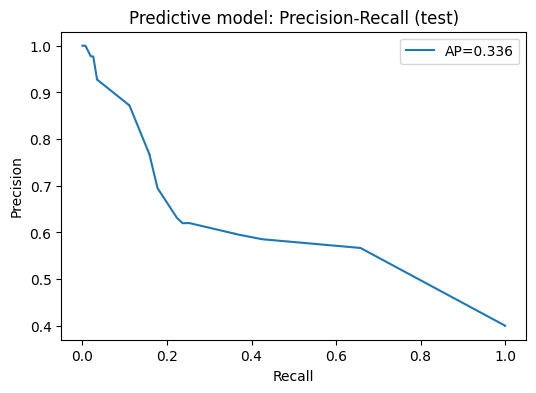

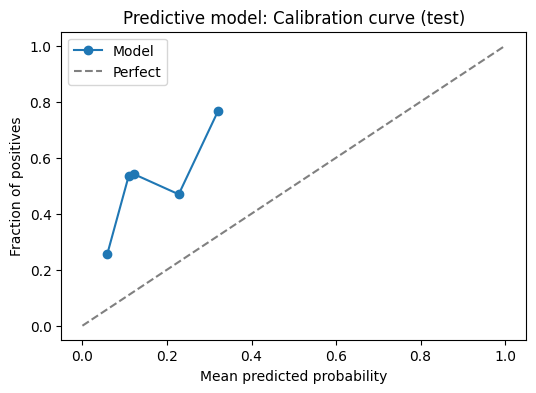


--- Starting Reactive Model Training ---
Sanitizing reactive data...
Training Regressors (Point, P10, P50, P90)...

Reactive MAE: 6.741
Reactive RMSE: 12.130
Reactive 80% interval coverage (P10..P90): 0.574


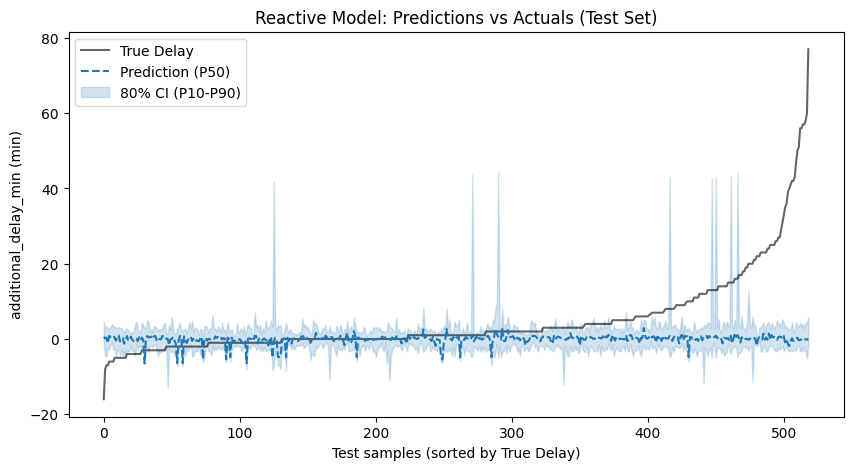

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CORRECT IMPORTS ---
from sklearn.metrics import precision_recall_curve, mean_absolute_error, mean_squared_error
from sklearn.calibration import calibration_curve  # <--- Fixed import location
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create output dir for plots
os.makedirs('data/models', exist_ok=True)

# ==========================================
# 1. VISUALIZE PREDICTIVE MODEL (PR & Calibration)
# ==========================================
print("Generating Predictive Model plots...")

# PR Curve
prec, rec, _ = precision_recall_curve(y_pred_test, test_proba)
plt.figure(figsize=(6, 4))
plt.plot(rec, prec, label=f"AP={best_ap:.3f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Predictive model: Precision-Recall (test)')
plt.legend()
plt.savefig('data/models/predictive_pr_curve.png', dpi=160, bbox_inches='tight')
plt.show()

# Calibration Curve
frac_pos, mean_pred = calibration_curve(y_pred_test, test_proba, n_bins=10, strategy='quantile')
plt.figure(figsize=(6, 4))
plt.plot(mean_pred, frac_pos, marker='o', label="Model")
plt.plot([0,1],[0,1], linestyle='--', color='gray', label="Perfect")
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Predictive model: Calibration curve (test)')
plt.legend()
plt.savefig('data/models/predictive_calibration_curve.png', dpi=160, bbox_inches='tight')
plt.show()

# ==========================================
# 2. REACTIVE MODEL (Severity)
# ==========================================
print("\n--- Starting Reactive Model Training ---")

# --- A. CLEANING (Crucial Step!) ---
def enforce_types(df, cat_cols, num_cols):
    df_out = df.copy()
    # Force categorical to string (fixes list/array issues)
    for c in cat_cols:
        if c in df_out.columns:
            df_out[c] = df_out[c].astype(str).replace("nan", np.nan)
    # Force numeric to float
    for c in num_cols:
        if c in df_out.columns:
            df_out[c] = pd.to_numeric(df_out[c], errors='coerce')
    return df_out

# 1. Drop known bad columns first
bad_cols = ["reason_text", "trigger_time", "Deviation", "InformationOwner"]
for df in [X_re_train, X_re_test]:
    existing = [c for c in bad_cols if c in df.columns]
    if existing:
        df.drop(columns=existing, inplace=True)

# 2. Infer types & Sanitize
cat_re = X_re_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_re = [c for c in X_re_train.columns if c not in cat_re]

print("Sanitizing reactive data...")
X_re_train_clean = enforce_types(X_re_train, cat_re, num_re)
X_re_test_clean = enforce_types(X_re_test, cat_re, num_re)

# --- B. DEFINE PREPROCESSOR ---
prep_re = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_re),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median"))
        ]), num_re),
    ],
    remainder="drop",
)

# --- C. TRAIN MODELS (Point + Quantiles) ---
print("Training Regressors (Point, P10, P50, P90)...")
common_params = {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 3}

# Point (Mean/MSE)
re_point = Pipeline([
    ("prep", prep_re),
    ("reg", GradientBoostingRegressor(loss="squared_error", **common_params)),
])

# Quantiles
re_q10 = Pipeline([("prep", prep_re), ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.1, **common_params))])
re_q50 = Pipeline([("prep", prep_re), ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.5, **common_params))])
re_q90 = Pipeline([("prep", prep_re), ("reg", GradientBoostingRegressor(loss="quantile", alpha=0.9, **common_params))])

# Fit
re_point.fit(X_re_train_clean, y_re_train)
re_q10.fit(X_re_train_clean, y_re_train)
re_q50.fit(X_re_train_clean, y_re_train)
re_q90.fit(X_re_train_clean, y_re_train)

# ... (Training code remains the same) ...

# --- D. EVALUATE ---
p_point = re_point.predict(X_re_test_clean)
p10 = re_q10.predict(X_re_test_clean)
p50 = re_q50.predict(X_re_test_clean)
p90 = re_q90.predict(X_re_test_clean)

# Metrics
mae = mean_absolute_error(y_re_test, p_point)

# FIX: Calculate RMSE manually to avoid version errors
mse = mean_squared_error(y_re_test, p_point)
rmse = np.sqrt(mse)

covered_80 = np.mean((y_re_test >= p10) & (y_re_test <= p90))

print(f"\nReactive MAE: {mae:.3f}")
print(f"Reactive RMSE: {rmse:.3f}")
print(f"Reactive 80% interval coverage (P10..P90): {covered_80:.3f}")

# --- E. PLOT INTERVALS ---
plt.figure(figsize=(10, 5))
# sort by true value for a clean plot
idx = np.argsort(y_re_test.to_numpy())

# Optional: Subsample if test set is huge (>1000 points) for cleaner plot
if len(idx) > 1000:
    idx = idx[::len(idx)//500] 

y_sorted = y_re_test.to_numpy()[idx]
plt.plot(y_sorted, label='True Delay', color='black', alpha=0.6, linewidth=1.5)
plt.plot(p50[idx], label='Prediction (P50)', color='tab:blue', linestyle='--', linewidth=1.5)
plt.fill_between(range(len(idx)), p10[idx], p90[idx], color='tab:blue', alpha=0.2, label='80% CI (P10-P90)')

plt.xlabel('Test samples (sorted by True Delay)')
plt.ylabel(f'{REACTIVE_TARGET} (min)')
plt.title('Reactive Model: Predictions vs Actuals (Test Set)')
plt.legend()
plt.savefig('data/models/reactive_intervals.png', dpi=160, bbox_inches='tight')
plt.show()





## 💾 Persist artifacts

We save:
- `predictive_model.pkl` (best uncalibrated pipeline)
- `calibrator.pkl` (isotonic calibrator wrapping the predictive model)
- `reactive_model.pkl` (dict containing point + quantile pipelines)
- `metrics.json` + plots

In [54]:
ART_DIR = 'data/models'
os.makedirs(ART_DIR, exist_ok=True)

# Save predictive artifacts
predictive_model_path = os.path.join(ART_DIR, 'predictive_model.pkl')
calibrator_path       = os.path.join(ART_DIR, 'calibrator.pkl')
joblib.dump(best_model, predictive_model_path)
joblib.dump(calibrator, calibrator_path)

# Save reactive artifacts (bundle all)
reactive_bundle = {
    "point": re_point,
    "q10": re_q10,
    "q50": re_q50,
    "q90": re_q90,
    "target": REACTIVE_TARGET,
}
reactive_model_path = os.path.join(ART_DIR, 'reactive_model.pkl')
joblib.dump(reactive_bundle, reactive_model_path)

metrics = {
    "predictive": {
        "best_params": best_params,
        "test_pr_auc": float(pr_auc),
        "test_brier": float(brier),
    },
    "reactive": {
        "target": REACTIVE_TARGET,
        "test_mae": float(mae),
        "test_rmse": float(rmse),
        "test_interval_coverage_p10_p90": float(covered_80),
    },
}

with open(os.path.join(ART_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved:')
print('-', predictive_model_path)
print('-', calibrator_path)
print('-', reactive_model_path)
print('-', os.path.join(ART_DIR, 'metrics.json'))


Saved:
- data/models/predictive_model.pkl
- data/models/calibrator.pkl
- data/models/reactive_model.pkl
- data/models/metrics.json


In [56]:
import hopsworks
from hsml.schema import Schema
from hsml.model_schema import ModelSchema
import joblib
import os

# 1. Login
project = hopsworks.login()
mr = project.get_model_registry()

# --- HELPER: Delete old models if they exist ---
# This prevents the "version already exists" error
try:
    existing_pred = mr.get_model("train_delay_model_pred", version=1)
    existing_pred.delete()
    print("🗑️ Deleted existing predictive model v1")
except:
    pass # Model didn't exist, safe to proceed

try:
    existing_react = mr.get_model("train_delay_model_react", version=1)
    existing_react.delete()
    print("🗑️ Deleted existing reactive model v1")
except:
    pass
# -----------------------------------------------

# ---------------------------------------
# A. Register Predictive Model
# ---------------------------------------
pred_metrics_clean = {
    "test_pr_auc": float(metrics["predictive"]["test_pr_auc"]),
    "test_brier": float(metrics["predictive"]["test_brier"])
}

input_schema_pred = Schema(X_pred_train_clean)
output_schema_pred = Schema(y_pred_train)
model_schema_pred = ModelSchema(input_schema_pred, output_schema_pred)

print("Registering Predictive Model...")
pred_model = mr.python.create_model(
    name="train_delay_model_pred",
    version=1,
    metrics=pred_metrics_clean,
    model_schema=model_schema_pred,
    description="Binary Delay Prediction (Calibrated)."
)
pred_model.save(calibrator_path)
print("✅ Predictive model registered!")

# ---------------------------------------
# B. Register Reactive Model
# ---------------------------------------
react_metrics_clean = {
    "test_mae": float(metrics["reactive"]["test_mae"]),
    "test_rmse": float(metrics["reactive"]["test_rmse"]),
    "test_interval_coverage": float(metrics["reactive"]["test_interval_coverage_p10_p90"])
}

input_schema_react = Schema(X_re_train_clean)
output_schema_react = Schema(y_re_train)
model_schema_react = ModelSchema(input_schema_react, output_schema_react)

print("Registering Reactive Model...")
react_model = mr.python.create_model(
    name="train_delay_model_react",
    version=1,
    metrics=react_metrics_clean,
    model_schema=model_schema_react,
    description="Reactive Delay Severity (Point + Quantiles)."
)
react_model.save(reactive_model_path)
print("✅ Reactive model registered!")

2026-01-06 17:00:13,314 INFO: Closing external client and cleaning up certificates.
2026-01-06 17:00:13,318 INFO: Connection closed.
2026-01-06 17:00:13,321 INFO: Initializing external client
2026-01-06 17:00:13,322 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-01-06 17:00:14,221 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/2182
Registering Predictive Model...


  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /home/ololpol/ScalML/Train_Delay_Predictor/data/models/calibrator.pkl: 0.000%|          | 0/272939 e…

Uploading /home/ololpol/ScalML/Train_Delay_Predictor/model_schema.json: 0.000%|          | 0/3056 elapsed<00:0…

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/2182/models/train_delay_model_pred/1
✅ Predictive model registered!
Registering Reactive Model...


  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /home/ololpol/ScalML/Train_Delay_Predictor/data/models/reactive_model.pkl: 0.000%|          | 0/1688…

Uploading /home/ololpol/ScalML/Train_Delay_Predictor/model_schema.json: 0.000%|          | 0/3065 elapsed<00:0…

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/2182/models/train_delay_model_react/1
✅ Reactive model registered!
